In [10]:
import ROOT
import fastjet
import math

In [11]:
import pandas as pd

In [12]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
f = ROOT.TFile.Open("/Users/rohanjagadeesan/Desktop/Code/li_lab/WinnerTakeAll/data/parton_data.root")
tree = f.Get("trackTree") 
tree.Print()

******************************************************************************
*Tree    :trackTree : v1                                                     *
*Entries :    75861 : Total =      1902448963 bytes  File  Size = 1149994732 *
*        :          : Tree compression factor =   1.65                       *
******************************************************************************
*Br    0 :par_pdgid : vector<int>                                            *
*Entries :    75861 : Total  Size=   45956101 bytes  File Size  =    7376237 *
*Baskets :     1458 : Basket Size=      32000 bytes  Compression=   6.23     *
*............................................................................*
*Br    1 :par_px    : vector<float>                                          *
*Entries :    75861 : Total  Size=   45951715 bytes  File Size  =   43269632 *
*Baskets :     1458 : Basket Size=      32000 bytes  Compression=   1.06     *
*...................................................

In [14]:
jet_radius = 1000 #just assuming some large value here. standard is 0.4 or 0.8. 

wta_def = fastjet.JetDefinition(fastjet.antikt_algorithm, jet_radius, fastjet.WTA_pt_scheme) #wta definition
std_def = fastjet.JetDefinition(fastjet.antikt_algorithm, jet_radius) #standard E scheme definition

In [16]:
#analysis cell  OLD VERSION

def make_pseudojets(pts, etas, phis):
    '''
    converts particles to pseudojets
    '''
    pj_list = []
    # pts is a single vector of particles for ONE jet
    for i in range(len(pts)): 
        p = fastjet.PseudoJet()
        p.reset_PtYPhiM(pts[i], etas[i], phis[i], 0.0)
        pj_list.append(p)
    return pj_list #list of pseudojets


jet_data = [] #list of dictionaries

#loopcount = 0 #for testing

# main event loop:
for event in tree:
    #loopcount+=1 #for testing
    #if loopcount>3:
    #    break

    # 1. Loop over jets in the event
    for ijet in range(event.genJetPt.size()):
        
        # 2. Get the daughter vectors for ONLY this jet
        dau_pts = event.genDau_pt[ijet]
        dau_etas = event.genDau_eta[ijet]
        dau_phis = event.genDau_phi[ijet]

        # 3. Create PseudoJets for this specific jet
        jet_constituents = make_pseudojets(dau_pts, dau_etas, dau_phis)

        # 4. Cluster with WTA and standard to find the new axis
        wta_clustered = fastjet.ClusterSequence(jet_constituents, wta_def)
        wta_jets = fastjet.sorted_by_pt(wta_clustered.inclusive_jets())

        std_clustered = fastjet.ClusterSequence(jet_constituents, std_def)
        std_jets = fastjet.sorted_by_pt(std_clustered.inclusive_jets())
        

        if len(wta_jets) > 0: #preventing indexing errors
            wta_jet = wta_jets[0]
            std_jet = std_jets[0]
            
            # Extract Std values FROM ROOT DATA
            std_pt = event.genJetPt[ijet]
            std_eta = event.genJetEta[ijet]
            std_phi = event.genJetPhi[ijet]
            
            # Extract WTA values
            wta_pt = wta_jet.pt()
            wta_eta = wta_jet.eta()
            wta_phi = wta_jet.phi()

            # Extract std values FROM PSEUDOJETS
            std_pt_pj = std_jet.pt()
            std_eta_pj = std_jet.eta()
            std_phi_pj = std_jet.phi()
            
            # Calculate dR
            dEta = std_eta_pj - wta_eta 
            dPhi = ROOT.TVector2.Phi_mpi_pi(std_phi_pj - wta_phi)  
            dR = math.sqrt(dEta**2 + dPhi**2)
            
            # Save all the useful info for this specific jet in a dictionary
            jet_info = {
                "std_pt": std_pt_pj,
                "wta_pt": wta_pt,
                "dR": dR,
                "multiplicity": len(jet_constituents), # how many constituents
                "dEta": dEta,
                "dPhi": dPhi
            }
            
            # Add to our main list
            jet_data.append(jet_info)

In [22]:
df = pd.DataFrame(jet_data)
print(df)

            std_pt      wta_pt        dR  multiplicity      dEta      dPhi
0       487.990206  492.699825  0.114905            65 -0.106475 -0.043201
1       605.768092  605.976328  0.007306            27  0.000997 -0.007238
2       627.858132  628.266330  0.005277            29 -0.000077 -0.005277
3       525.089004  526.719417  0.017777            53  0.002198 -0.017640
4       509.240681  516.351482  0.154653            83 -0.017869 -0.153618
...            ...         ...       ...           ...       ...       ...
112495  610.816057  611.557239  0.002918            33 -0.001020 -0.002734
112496  576.560727  584.485795  0.170217            83  0.011743 -0.169811
112497  620.016765  621.778850  0.003327            38 -0.001581 -0.002927
112498  696.624092  698.866020  0.158116            49 -0.158085  0.003162
112499  508.322851  513.848773  0.037085            61 -0.005734 -0.036639

[112500 rows x 6 columns]


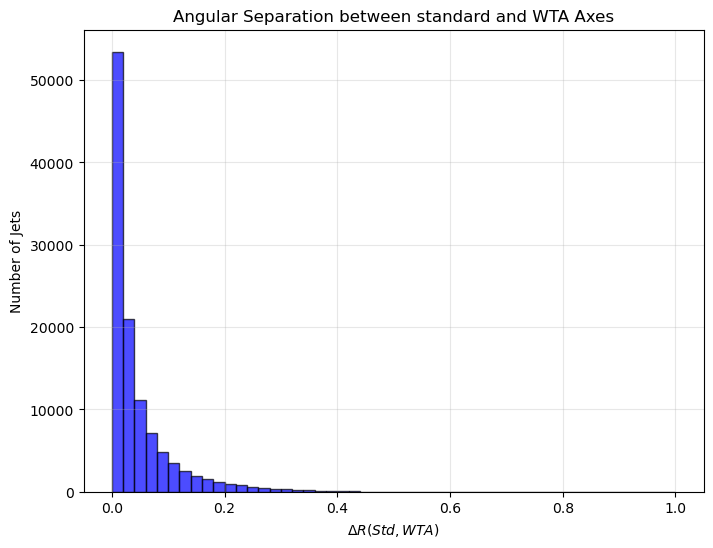

In [18]:
#number of jets for a given dR

plt.figure(figsize=(8, 6))

# Plot a histogram of the dR column
plt.hist(df['dR'], bins=50, range=(0, 1), color='blue', alpha=0.7, edgecolor='black') #standard jet radius is 0.5

plt.title('Angular Separation between standard and WTA Axes')
plt.xlabel(r'$\Delta R(Std, WTA)$')
plt.ylabel('Number of Jets')
#plt.yscale('log') # Log scale is standard for this distribution
plt.grid(True, alpha=0.3)
plt.show()

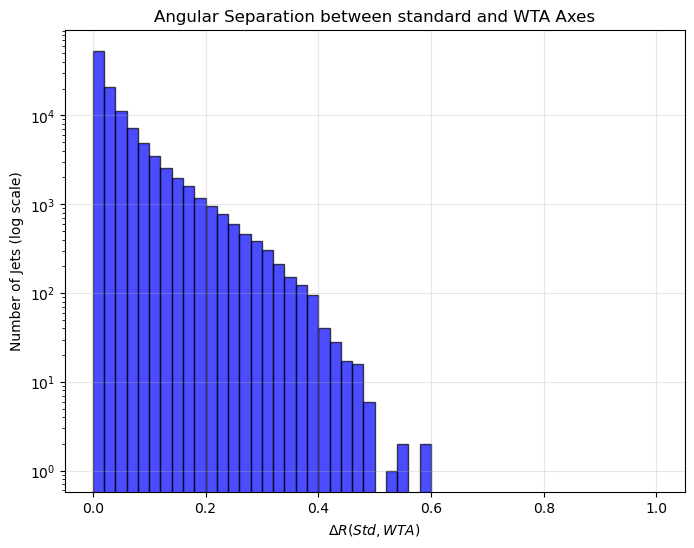

In [19]:
#same thing with log scale y

plt.figure(figsize=(8, 6))

# Plot a histogram of the dR column
plt.hist(df['dR'], bins=50, range=(0, 1), color='blue', alpha=0.7, edgecolor='black')

#labelling
plt.title('Angular Separation between standard and WTA Axes')
plt.xlabel(r'$\Delta R(Std, WTA)$')
plt.ylabel('Number of Jets (log scale)')
plt.yscale('log') 
plt.grid(True, alpha=0.3)
plt.show()

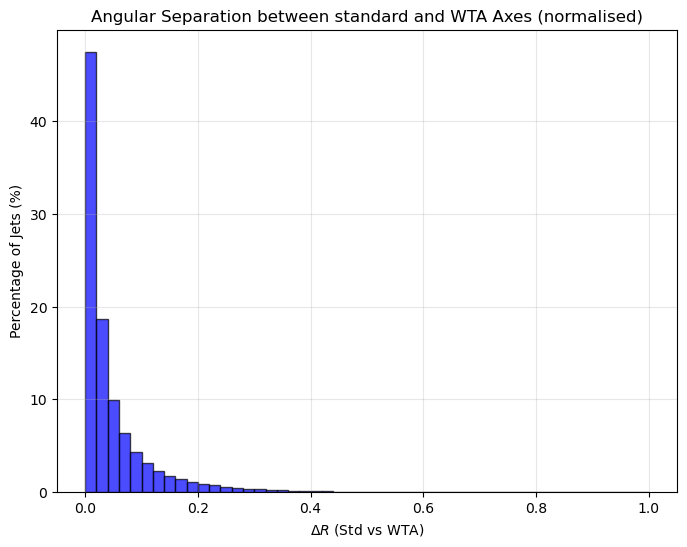

In [20]:
# number of jets thing but normalised / as a percentage

# 1. Create an array where every jet is weighted as a percentage of the total
total_jets = len(df['dR'])
weights = np.ones(total_jets) / total_jets * 100

plt.figure(figsize=(8, 6))

# 2. Add the 'weights' parameter to your histogram
plt.hist(df['dR'], bins=50, range=(0, 1), weights=weights, color='blue', alpha=0.7, edgecolor='black')

plt.title(r'Angular Separation between standard and WTA Axes (normalised)')
plt.xlabel(r'$\Delta R$ (Std vs WTA)')
plt.ylabel('Percentage of Jets (%)') # Updated label!
plt.grid(True, alpha=0.3)

plt.show()

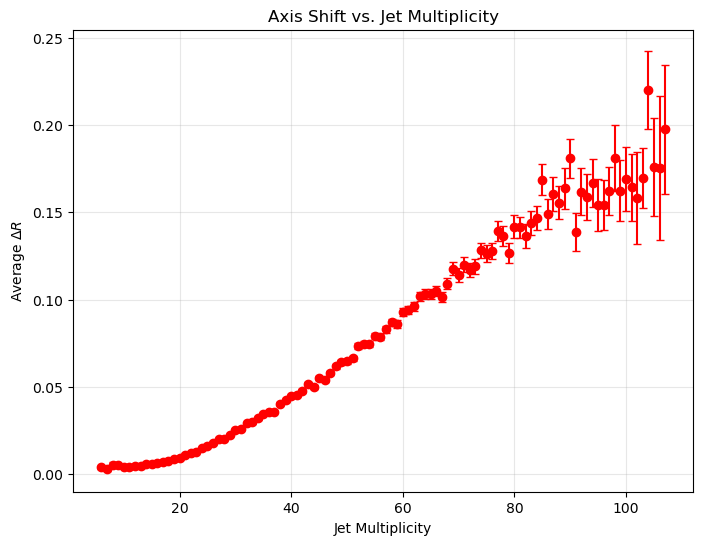

In [21]:
#average axis shift vs jet multiplicity

plt.figure(figsize=(8, 6))

# Group by multiplicity and calculate the mean and std deviation of dR
grouped = df.groupby('multiplicity')['dR'].agg(['mean', 'std', 'count']) 

# Filter out bins with too few jets to avoid statistical noise
grouped = grouped[grouped['count'] > 10]

plt.errorbar(grouped.index, grouped['mean'], yerr=grouped['std']/np.sqrt(grouped['count']), 
             fmt='o', color='red', capsize=3)

plt.title('Axis Shift vs. Jet Multiplicity')
plt.xlabel('Jet Multiplicity')
plt.ylabel(r'Average $\Delta R$') #average dR for a given multiplicity
plt.grid(True, alpha=0.3)
plt.show()

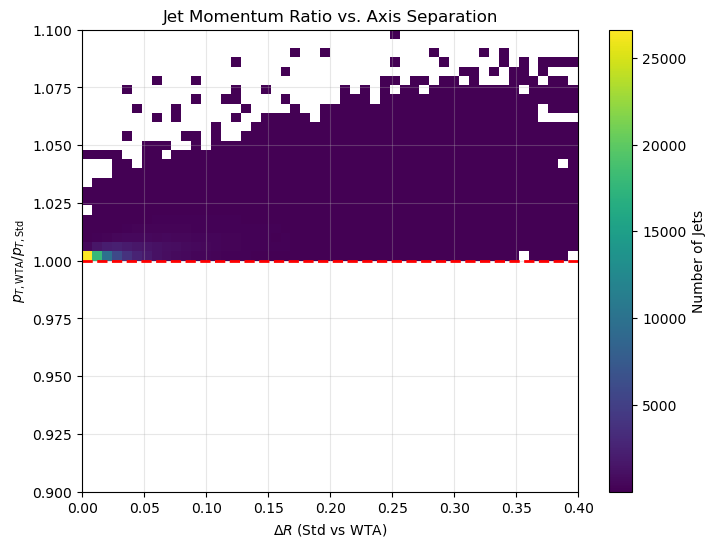

In [90]:
# ratio of wta_pt over std_pt, as a function of dR

# 1. Calculate the ratio and add it as a new column in your DataFrame
df['pt_ratio'] = df['wta_pt'] / df['std_pt']

plt.figure(figsize=(8, 6))

# 2. Create the 2D Histogram
# - bins=(50, 50) creates a 50x50 grid
# - range limits the axes so outliers don't ruin the scale
# - cmap='viridis' is a standard, colorblind-friendly colormap
# - cmin=1 makes bins with 0 jets transparent/white
h = plt.hist2d(df['dR'], df['pt_ratio'], 
               bins=(50, 50), 
               range=[[0, 0.4], [0.9, 1.1]],                   
               cmap='viridis', 
               cmin=1)

# 3. Add a colorbar to show what the colors mean (density of jets)
plt.colorbar(h[3], label='Number of Jets')

# 4. Add a horizontal reference line exactly at ratio = 1.0
plt.axhline(1.0, color='red', linestyle='dashed', linewidth=2)

# 5. Labels and styling
plt.title('Jet Momentum Ratio vs. Axis Separation')
plt.xlabel(r'$\Delta R$ (Std vs WTA)')
plt.ylabel(r'$p_{T, \mathrm{WTA}} / p_{T, \mathrm{Std}}$')
plt.grid(True, alpha=0.3)

plt.show()


#the ratio is only correct for clustered std pt, 
# otherwise you end up with WTA pt sometimes being less than std pt, which should not be possible by triangle inequality

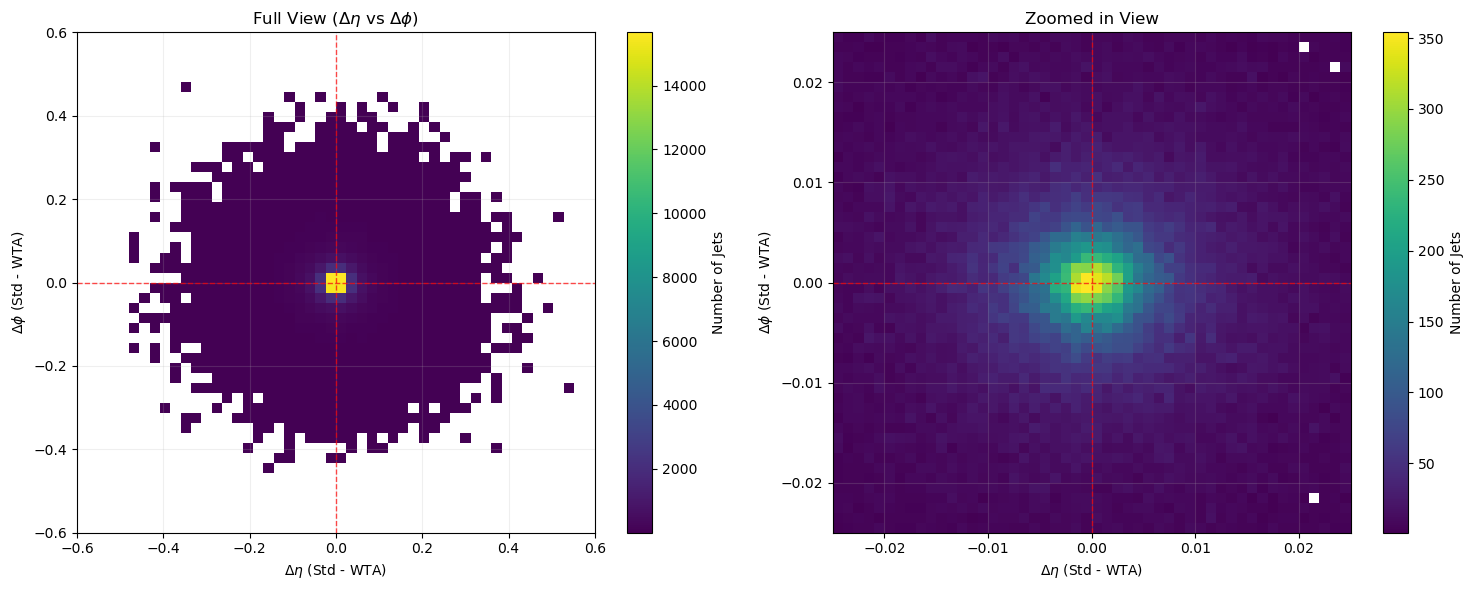

In [91]:
#number of jets vs dEta and dPhi

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

h1 = axes[0].hist2d(df['dEta'], df['dPhi'], 
                    bins=(50, 50), 
                    range=[[-0.6, 0.6], [-0.6, 0.6]],   #large range
                    cmap='viridis', 
                    cmin=1) #empty ones are white

# Attach the colorbar specifically to this subplot (ax=axes[0])
fig.colorbar(h1[3], ax=axes[0], label='Number of Jets')

# Add crosshairs, titles, and labels
axes[0].axvline(0, color='red', linestyle='dashed', linewidth=1, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='dashed', linewidth=1, alpha=0.7)
axes[0].set_title(r'Full View ($\Delta \eta$ vs $\Delta \phi$)')
axes[0].set_xlabel(r'$\Delta \eta$ (Std - WTA)')
axes[0].set_ylabel(r'$\Delta \phi$ (Std - WTA)')
axes[0].grid(True, alpha=0.2)


# Plot 2: The Zoomed-In 
h2 = axes[1].hist2d(df['dEta'], df['dPhi'], 
                    bins=(50, 50), 
                    range=[[-0.025, 0.025], [-0.025, 0.025]], 
                    cmap='viridis', 
                    cmin=1)

fig.colorbar(h2[3], ax=axes[1], label='Number of Jets')

# Add crosshairs, titles, and labels
axes[1].axvline(0, color='red', linestyle='dashed', linewidth=1, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='dashed', linewidth=1, alpha=0.7)
axes[1].set_title(r'Zoomed in View')
axes[1].set_xlabel(r'$\Delta \eta$ (Std - WTA)')
axes[1].set_ylabel(r'$\Delta \phi$ (Std - WTA)')
axes[1].grid(True, alpha=0.2)


# tight_layout() automatically adjusts spacing so the titles and labels don't overlap
plt.tight_layout()
plt.show()

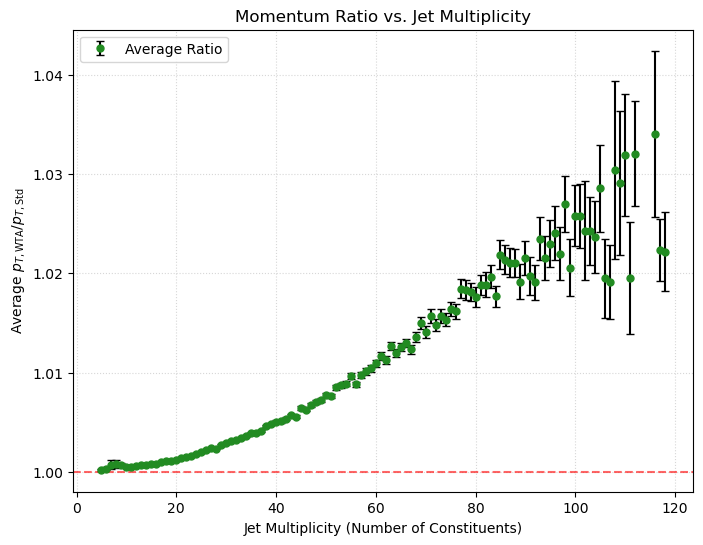

In [92]:
# ratio of wta_pt over std_pt, as a function of multiplicity

# 1. Calculate the ratio and add it as a new column in your DataFrame
#df['pt_ratio'] = df['wta_pt'] / df['std_pt']

# 2. Group the data by multiplicity
# We calculate the mean, standard deviation, and count for the error bars
stats = df.groupby('multiplicity')['pt_ratio'].agg(['mean', 'std', 'count'])

# 3. Filter out bins with very few jets to keep the plot clean
stats = stats[stats['count'] > 5]

plt.figure(figsize=(8, 6))

# 4. Plot using error bars
# x = multiplicity (the index of our grouped dataframe)
# y = mean ratio
# yerr = standard error (std / sqrt(count))
plt.errorbar(stats.index, stats['mean'], 
             yerr=stats['std'] / np.sqrt(stats['count']), 
             fmt='o', color='forestgreen', ecolor='black', 
             capsize=3, markersize=5, label='Average Ratio')

# 5. Add a reference line at 1.0
plt.axhline(1.0, color='red', linestyle='--', alpha=0.6)

# Formatting
plt.title(r'Momentum Ratio vs. Jet Multiplicity')
plt.xlabel('Jet Multiplicity (Number of Constituents)')
plt.ylabel(r'Average $p_{T, \mathrm{WTA}} / p_{T, \mathrm{Std}}$')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend()

plt.show()